In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%%bash
cd ..
python3 gen_file.py 34800 300 > hashing.txt
make -s

In [3]:
def gen_graphs(cdf):

    transitions = []
    c_elapsed_time = []
    java_elapsed_time = []
    idx = 0
    
    with open('../result.txt', 'r') as file:
        file_contents = file.read()
    
    lines = file_contents.split('\n')
    
    
    for i in range(0, len(lines), 3):
        transitions.append(lines[i])
    
    for i in range(1, len(lines), 3):
        c_elapsed_time.append(float(lines[i]))
    
    for i in range(2, len(lines), 3):
        java_elapsed_time.append(float(lines[i]))
    
    transitions.pop()
    transitions = [float(x) for x in transitions]
    java_elapsed_time = [float(x) for x in java_elapsed_time]
    c_elapsed_time = [float(x) for x in c_elapsed_time]
    java_elapsed_time_array = np.array(java_elapsed_time)
    c_elapsed_time_array = np.array(c_elapsed_time)
    data_overhead = java_elapsed_time_array - c_elapsed_time_array
    
    if not cdf:
        fig = plt.figure(figsize=(8, 4))
        plt.rc('font', size=8)
        plt.title("Transitions between Java code and Native Code")
        plt.xlabel("No. of Transitions")
        plt.ylabel("Time Elapsed (in seconds)")
        plt.plot(transitions,java_elapsed_time)
        
        plt.figure(2,figsize=(8, 4))
        plt.plot(transitions,data_overhead)
        plt.title("Cost of Data Transfer between Java Code and Native Code")
        plt.xlabel("No. of Transitions")
        plt.ylabel("Time Elapsed (in seconds)")
        plt.show()
    else:
        count, bins_count = np.histogram(data_overhead,bins=100000)
        pdf = count / sum(count)
        cdf = np.cumsum(pdf)
        plt.xlabel("Time Elapsed for Data Transfer between Java and C")
        plt.ylabel("Probability")
        plt.plot(bins_count[1:], cdf, label="CDF")
        plt.xlim(0, 0.00001)  # Set custom X-axis limits
        plt.ylim(0, 1.5)
        plt.legend()
        plt.show()

# 10 MB

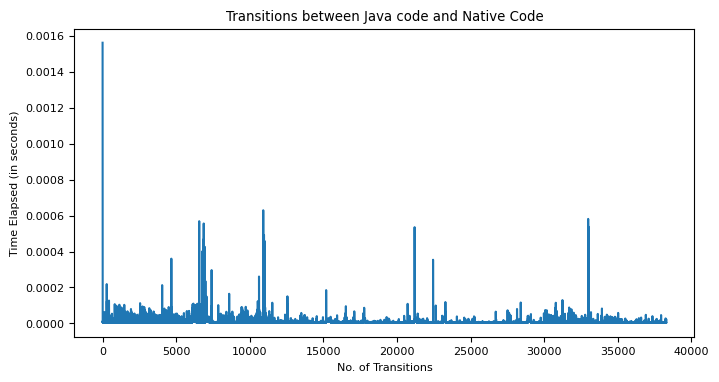

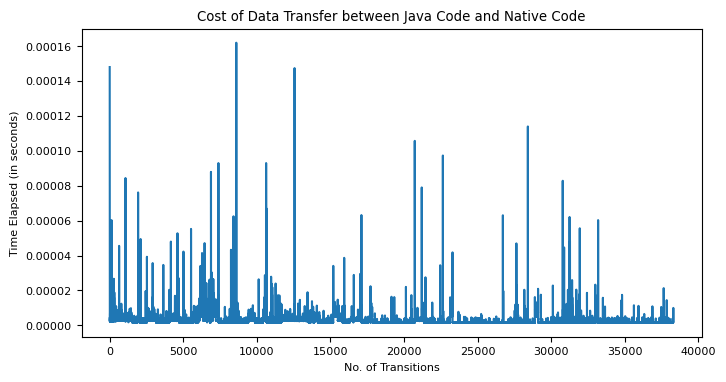

In [4]:
gen_graphs(False)

In [5]:
%%bash
cd ..
python3 gen_file.py 348 300 > hashing.txt
make -s

# 1 MB

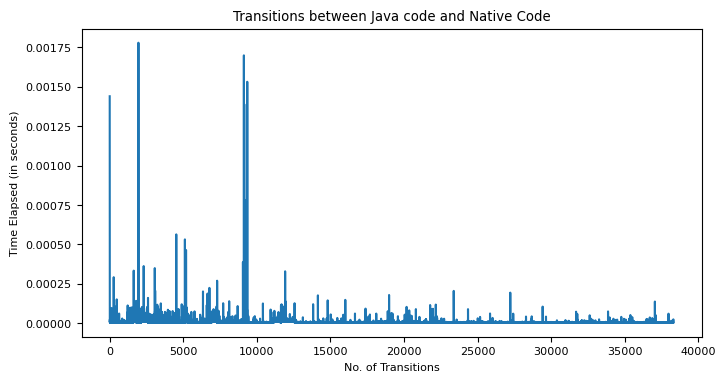

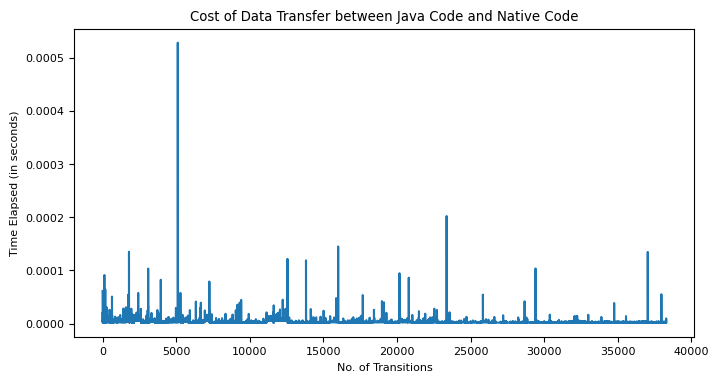

In [6]:
gen_graphs(False)

In [7]:
%%bash
cd ..
python3 gen_file.py 1005 100 > hashing.txt
make -s

# 100 KB

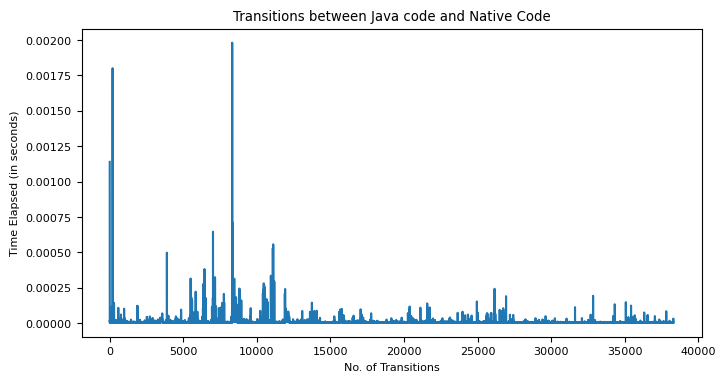

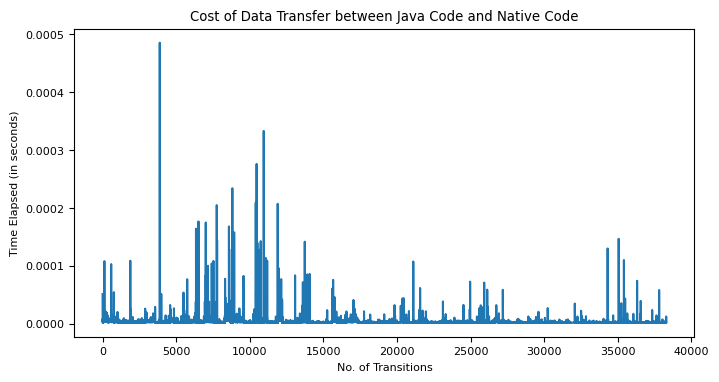

In [8]:
gen_graphs(False)

In [9]:
%%bash
cd ..
python3 gen_file.py 101 100 > hashing.txt
make -s

# 10 KB

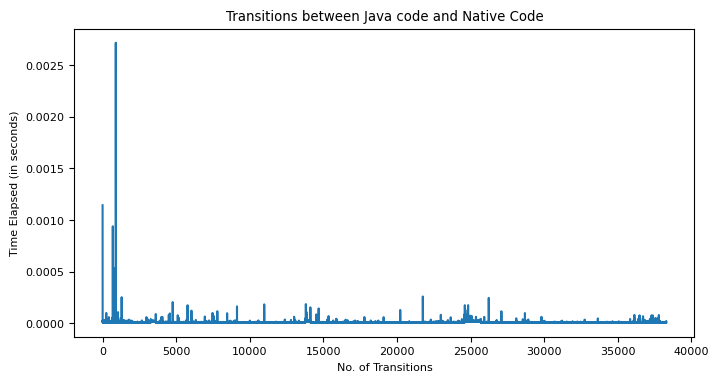

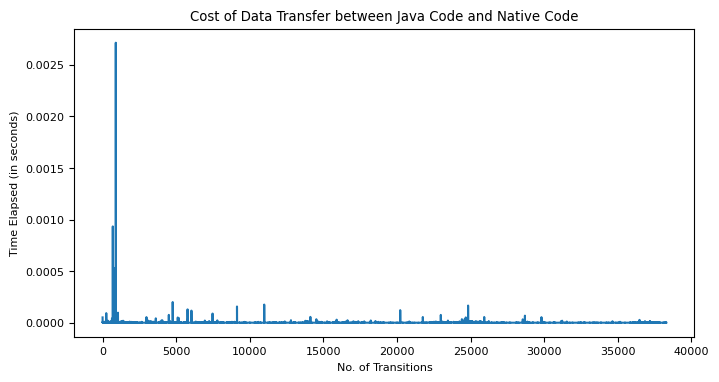

In [10]:
gen_graphs(False)

In [11]:
%%bash
cd ..
python3 gen_file.py 8 127 > hashing.txt
make -s

# 1 KB

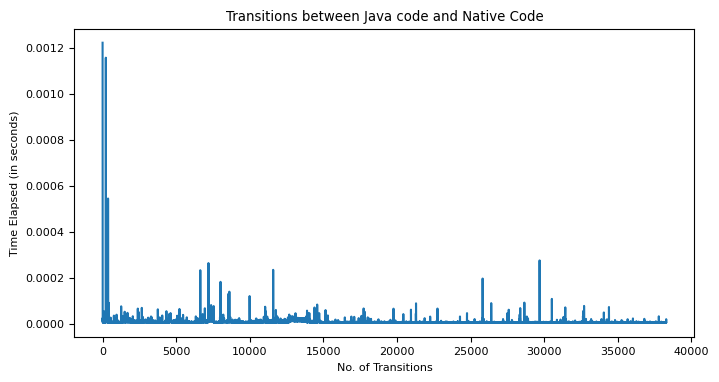

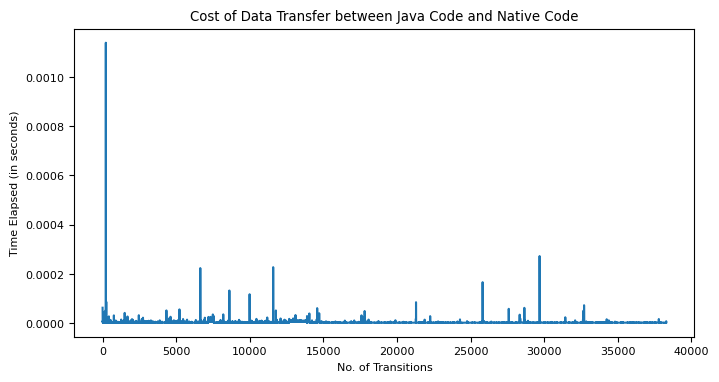

In [12]:
gen_graphs(False)

In [13]:
%%bash
cd ..
python3 gen_file.py 8 127 > hashing1.txt
make -s

In [14]:
transitions = []
c_elapsed_time = []
java_elapsed_time = []
idx = 0

with open('../result.txt', 'r') as file:
        file_contents = file.read()
    
lines = file_contents.split('\n')

for i in range(0, len(lines), 3):
    transitions.append(lines[i])

for i in range(1, len(lines), 3):
    c_elapsed_time.append(float(lines[i]))

for i in range(2, len(lines), 3):
    java_elapsed_time.append(float(lines[i]))

transitions.pop()
transitions = [float(x) for x in transitions]
java_elapsed_time = [float(x) for x in java_elapsed_time]
c_elapsed_time = [float(x) for x in c_elapsed_time]
java_elapsed_time_array = np.array(java_elapsed_time)
c_elapsed_time_array = np.array(c_elapsed_time)
data_overhead_1 = java_elapsed_time_array - c_elapsed_time_array

In [15]:
%%bash
cd ..
python3 gen_file.py 34800 3000 > hashing2.txt
make -s

In [16]:
transitions = []
c_elapsed_time = []
java_elapsed_time = []
idx = 0

with open('../result.txt', 'r') as file:
        file_contents = file.read()
    
lines = file_contents.split('\n')

for i in range(0, len(lines), 3):
    transitions.append(lines[i])

for i in range(1, len(lines), 3):
    c_elapsed_time.append(float(lines[i]))

for i in range(2, len(lines), 3):
    java_elapsed_time.append(float(lines[i]))

transitions.pop()
transitions = [float(x) for x in transitions]
java_elapsed_time = [float(x) for x in java_elapsed_time]
c_elapsed_time = [float(x) for x in c_elapsed_time]
java_elapsed_time_array = np.array(java_elapsed_time)
c_elapsed_time_array = np.array(c_elapsed_time)
data_overhead_2 = java_elapsed_time_array - c_elapsed_time_array

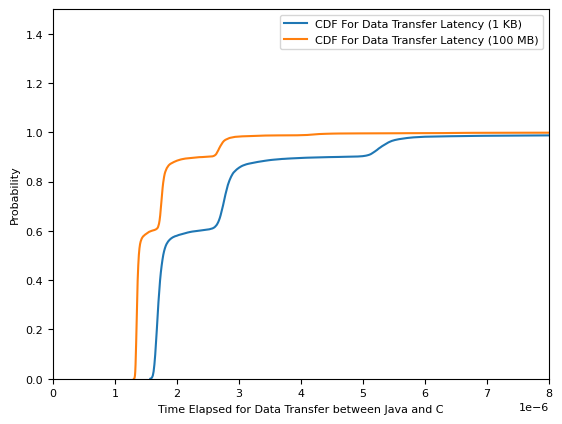

In [17]:
count, bins_count = np.histogram(data_overhead_1,bins=100000)
count_2, bins_count_2 = np.histogram(data_overhead_2,bins=100000)
pdf = count / sum(count)
pdf_2 = count_2 / sum(count_2)
cdf = np.cumsum(pdf)
cdf_2 = np.cumsum(pdf_2)
plt.xlabel("Time Elapsed for Data Transfer between Java and C")
plt.ylabel("Probability")
plt.plot(bins_count[1:], cdf, label="CDF For Data Transfer Latency (1 KB)")
plt.plot(bins_count_2[1:], cdf, label="CDF For Data Transfer Latency (100 MB)")
plt.xlim(0, 0.000008)  # Set custom X-axis limits
plt.ylim(0, 1.5)
plt.legend()
plt.show()